In [1]:
import sys
import os
import warnings
import joblib

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Importamos nuestra propia fábrica de datos
from src.data_processing import clean_and_engineer_features, preprocess_data

### Limpieza y creación de variables

In [3]:
# 1. Cargar datos brutos
train_raw = pd.read_csv('../data/raw/train.csv')
test_raw = pd.read_csv('../data/raw/test.csv')

# 2. Pipeline de limpieza e ingeniería de datos
train_clean = clean_and_engineer_features(train_raw, is_train=True)
test_clean = clean_and_engineer_features(test_raw, is_train=False)

### Preparación de datos

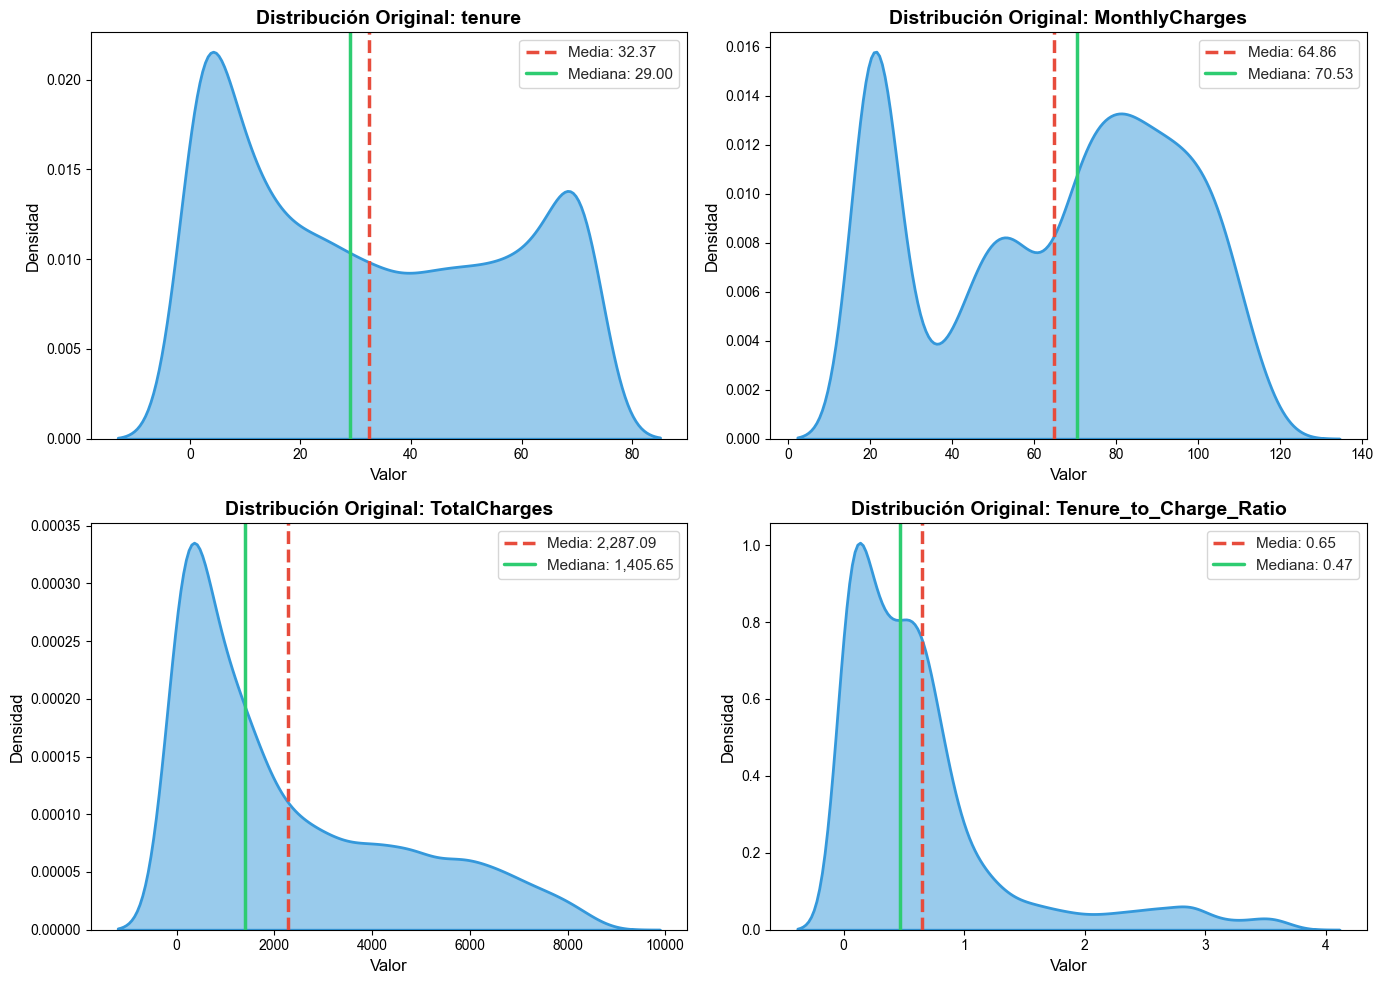

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Tenure_to_Charge_Ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(train_clean[col], fill=True, color='#3498db', alpha=0.5, linewidth=2, ax=axes[i])
    
    mean_val = train_clean[col].mean()
    median_val = train_clean[col].median()
    
    axes[i].axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Media: {mean_val:,.2f}')
    axes[i].axvline(median_val, color='#2ecc71', linestyle='-', linewidth=2.5, label=f'Mediana: {median_val:,.2f}')

    axes[i].set_title(f'Distribución Original: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=12)
    axes[i].set_ylabel('Densidad', fontsize=12)
    axes[i].legend()
    axes[i].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [5]:
# Evaluar necesidad de transformación de datos
pt_report = PowerTransformer(method='yeo-johnson', standardize=False)
pt_report.fit(train_clean[num_cols]) 

lambdas_df = pd.DataFrame({
    'Variable Numérica': num_cols,
    'Skewness Original': train_clean[num_cols].skew().values,
    'Lambda Óptimo (Yeo-Johnson)': pt_report.lambdas_
})

display(lambdas_df)

,Variable Numérica,Skewness Original,Lambda Óptimo (Yeo-Johnson)
0,tenure,0.239946,0.450998
1,MonthlyCharges,-0.226248,0.932787
2,TotalCharges,0.956097,0.260282
3,Tenure_to_Charge_Ratio,2.093370,-1.343711


In [6]:
# Separamos el 80% (Train) y 20% (Validation) ANTES de cualquier transformación global
train_local_df, val_local_df = train_test_split(
    train_clean, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_clean['Churn'] # Mantenemos el 26% de churn
)

# 4. Transformación, One-Hot Encoding y Escalado (Yeo-Johnson)
X_train, X_val, X_test_kaggle, y_train, y_val, test_ids = preprocess_data(train_local_df, val_local_df, test_clean)

print("--- PARTICIÓN Y PREPROCESAMIENTO SIN LEAKAGE COMPLETADO ---")
print(f"Data para entrenar (Train Local): {X_train.shape[0]} clientes")
print(f"Data para evaluar (Validation Local): {X_val.shape[0]} clientes")
print(f"Data ciega para Kaggle (Test Oficial): {X_test_kaggle.shape[0]} clientes")

--- PARTICIÓN Y PREPROCESAMIENTO SIN LEAKAGE COMPLETADO ---
Data para entrenar (Train Local): 4507 clientes
Data para evaluar (Validation Local): 1127 clientes
Data ciega para Kaggle (Test Oficial): 1409 clientes


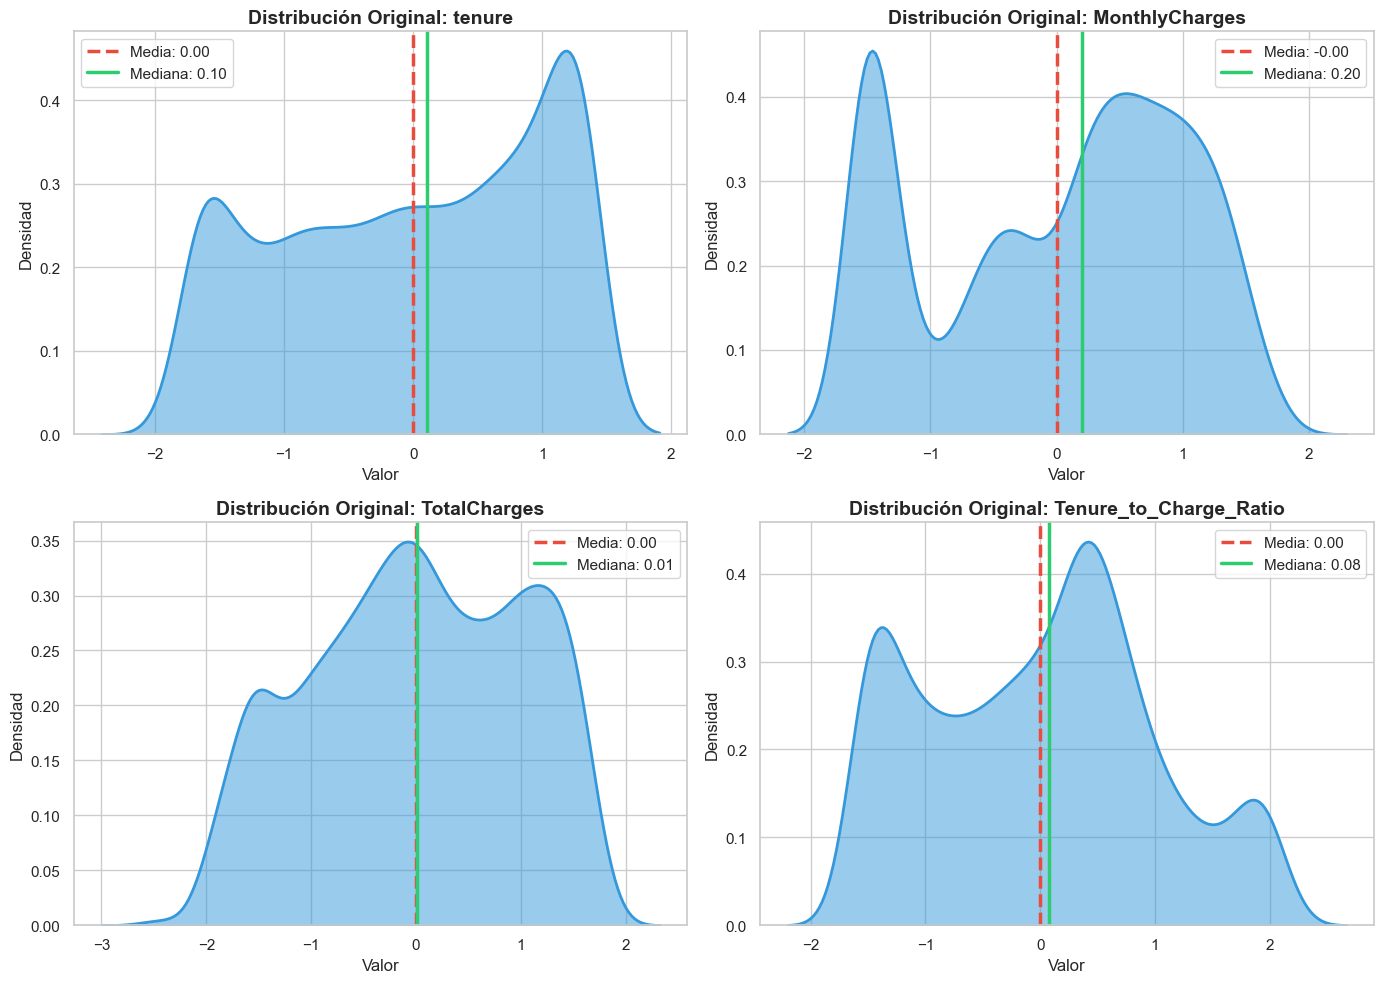

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Tenure_to_Charge_Ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Gráfico de densidad (KDE) apuntando a axes[i]
    sns.kdeplot(X_train[col], fill=True, color='#3498db', alpha=0.5, linewidth=2, ax=axes[i])
    
    # Calcular Media y Mediana
    mean_val = X_train[col].mean()
    median_val = X_train[col].median()
    
    # Líneas verticales apuntando a axes[i]
    axes[i].axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Media: {mean_val:,.2f}')
    axes[i].axvline(median_val, color='#2ecc71', linestyle='-', linewidth=2.5, label=f'Mediana: {median_val:,.2f}')

    # Títulos y etiquetas dinámicas apuntando a axes[i]
    axes[i].set_title(f'Distribución Original: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=12)
    axes[i].set_ylabel('Densidad', fontsize=12)
    axes[i].legend()
    axes[i].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

### Multicolinealidad e Impacto de variables


--- VIF de Variables Cuantitativas ---


,Variable,VIF
0,tenure,85.721449
1,TotalCharges,56.278998
2,Tenure_to_Charge_Ratio,27.872123
3,MonthlyCharges,12.226374


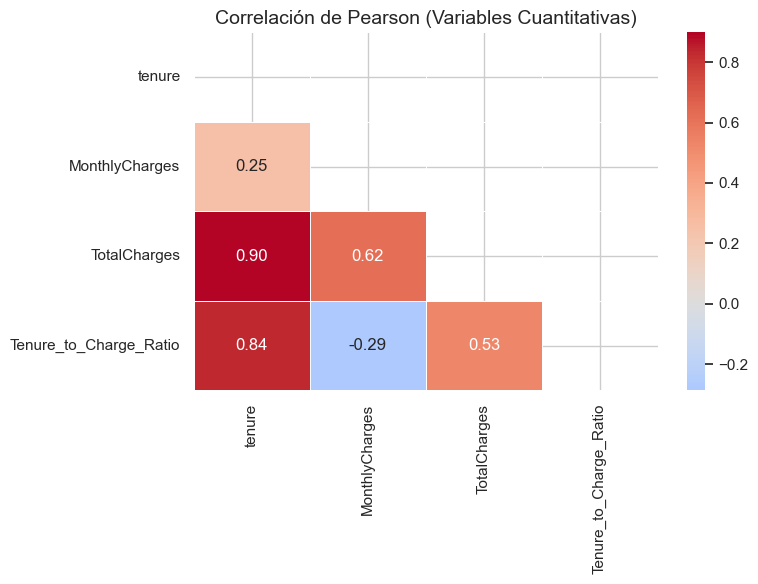

In [8]:
# MULTICOLINEALIDAD - VARIABLES NUMÉRICAS

X_train_num = X_train[num_cols].astype(float)

# Cálculo VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_num.values, i) for i in range(len(X_train_num.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- VIF de Variables Cuantitativas ---")
display(vif_data)

# 6. Heatmap de Correlación de Pearson
plt.figure(figsize=(8, 6))
corr_matrix_num = X_train_num.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix_num, dtype=bool))
sns.heatmap(corr_matrix_num, mask=mask, cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=.5)
plt.title('Correlación de Pearson (Variables Cuantitativas)', fontsize=14)
plt.tight_layout()
plt.show()

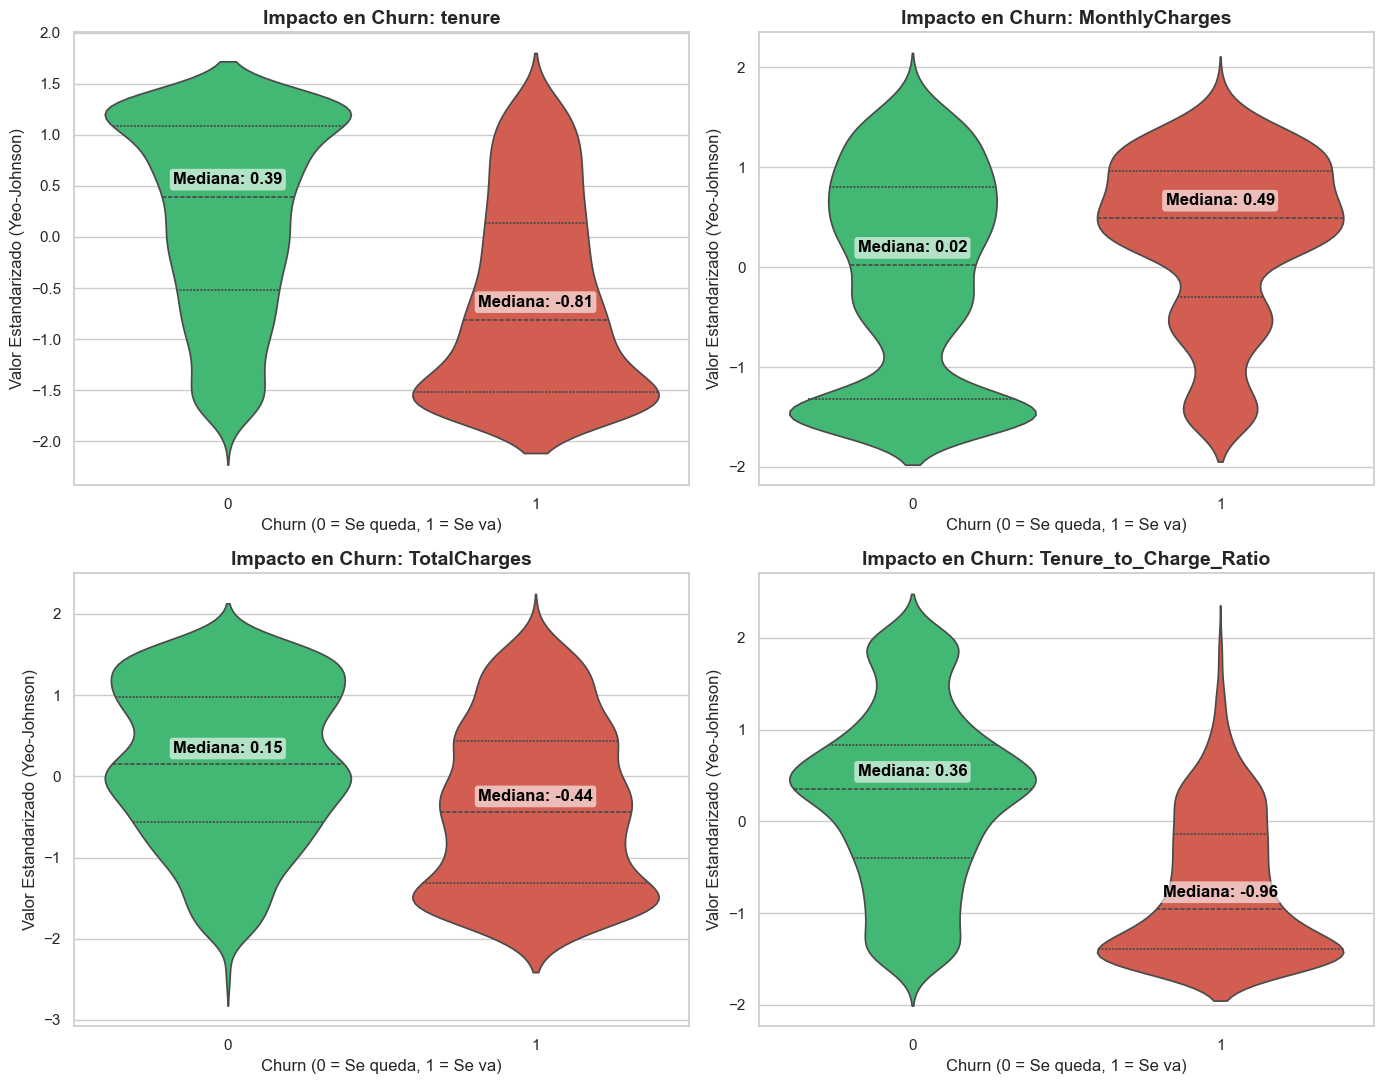

In [9]:
# IMPACTO DE VARIABLES NUMERICAS PREDICTORAS EN CHURN

df_viz = X_train_num.copy()
df_viz['Churn'] = y_train.values 


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

colores_churn = ['#2ecc71', '#e74c3c']

for i, col in enumerate(num_cols):
    sns.violinplot(
        x='Churn', 
        y=col, 
        data=df_viz, 
        ax=axes[i], 
        hue='Churn',
        legend=False,
        palette=colores_churn, 
        inner='quartile' 
    )
    
    # Calculamos la mediana real para Churn=0 y Churn=1
    mediana_0 = df_viz[df_viz['Churn'] == 0][col].median()
    mediana_1 = df_viz[df_viz['Churn'] == 1][col].median()
    
    # Colocar el texto sobre el gráfico (x=0 para No Churn, x=1 para Churn)
    axes[i].text(0, mediana_0 + 0.1, f'Mediana: {mediana_0:.2f}', 
                 color='black', weight='bold', ha='center', va='bottom',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
    
    axes[i].text(1, mediana_1 + 0.1, f'Mediana: {mediana_1:.2f}', 
                 color='black', weight='bold', ha='center', va='bottom',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
    # -----------------------------------------------------------
    
    axes[i].set_title(f'Impacto en Churn: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Churn (0 = Se queda, 1 = Se va)', fontsize=12)
    axes[i].set_ylabel('Valor Estandarizado (Yeo-Johnson)', fontsize=12)

plt.tight_layout()
plt.show()

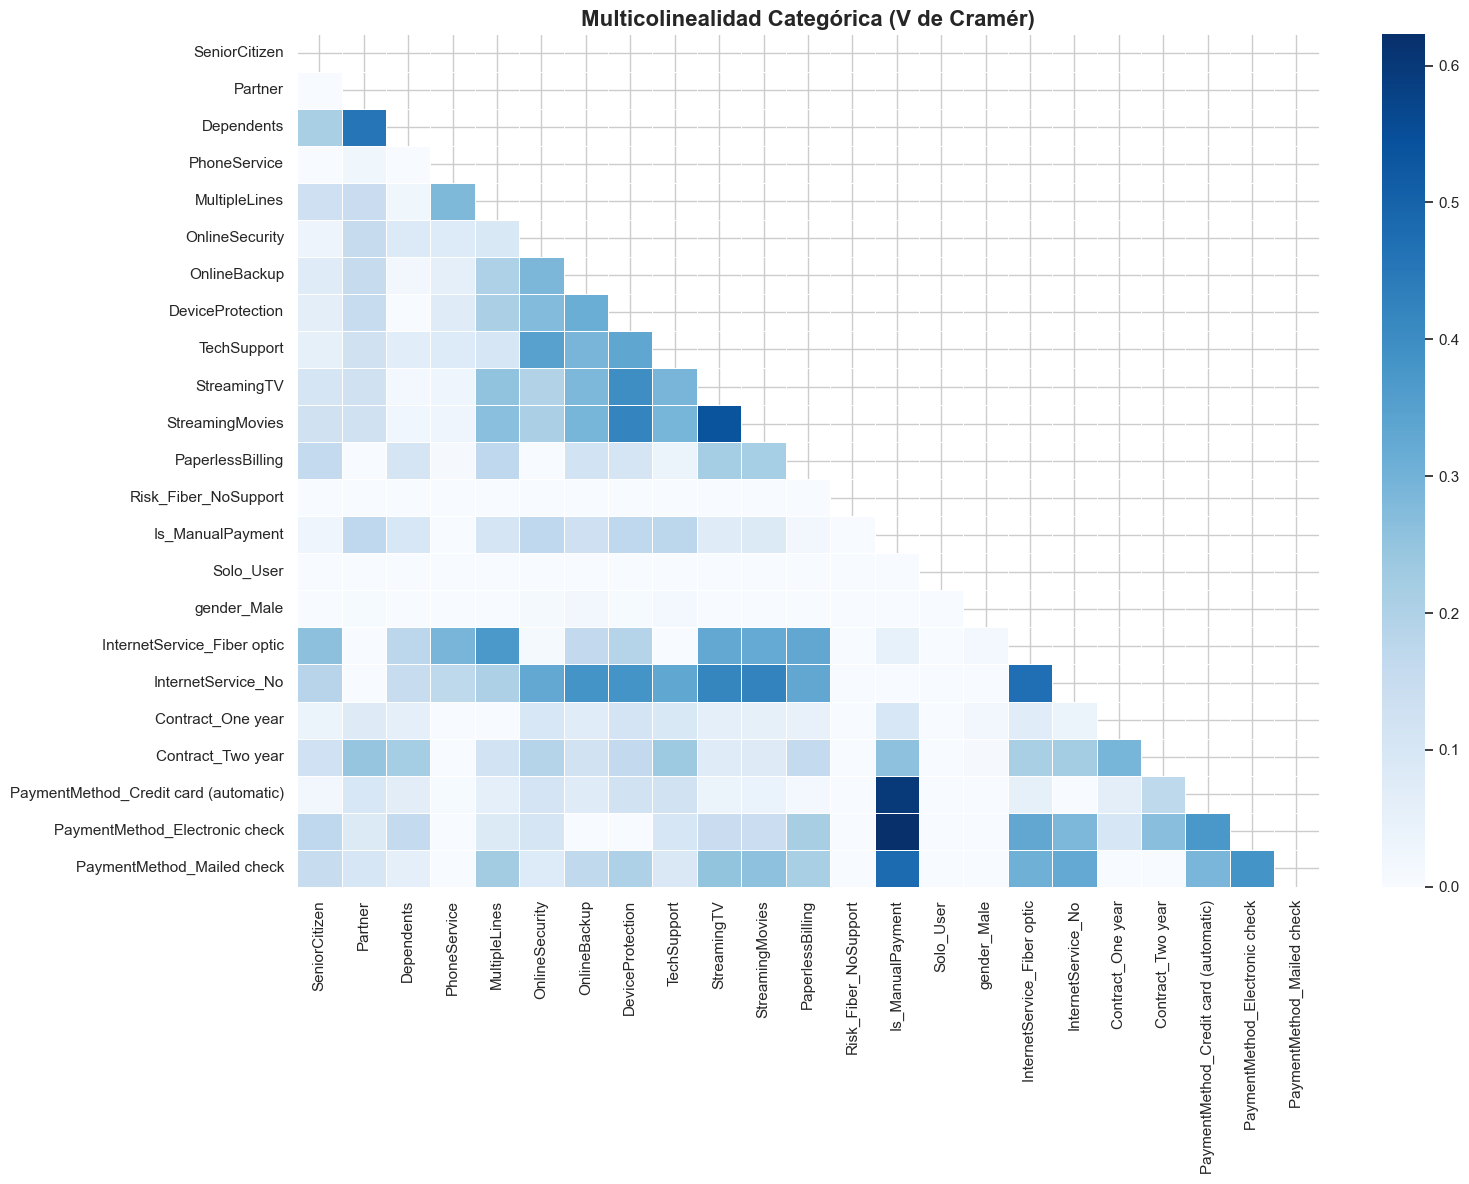


--- Pares Categóricos con alta redundancia (V > 0.6) ---


,Variable 1,Variable 2,V de Cramér
0,Is_ManualPayment,PaymentMethod_Electronic check,0.622728


In [10]:
# MULTICOLINEALIDAD - VARIABLES CATEGORICAS

num_cols_final = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Tenure_to_Charge_Ratio', 'Total_Addons']
cat_cols = [col for col in X_train.columns if col not in num_cols_final]
X_train_cat = X_train[cat_cols]

# Función matemática para calcular la V de Cramér con corrección de sesgo
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Evitar divisiones por cero
    min_dim = min((kcorr-1), (rcorr-1))
    if min_dim == 0:
        return 0.0
    return np.sqrt(phi2corr / min_dim)

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(X_train_cat[col1], X_train_cat[col2])
        
cramer_matrix = cramer_matrix.astype(float)

# Graficamos el Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))
sns.heatmap(cramer_matrix, mask=mask, cmap='Blues', annot=False, linewidths=.5)
plt.title("Multicolinealidad Categórica (V de Cramér)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Extraer los pares más problemáticos (V > 0.6)
print("\n--- Pares Categóricos con alta redundancia (V > 0.6) ---")
pares_altos = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        if cramer_matrix.iloc[i, j] > 0.6:
            pares_altos.append((cat_cols[i], cat_cols[j], cramer_matrix.iloc[i, j]))

pares_df = pd.DataFrame(pares_altos, columns=['Variable 1', 'Variable 2', 'V de Cramér'])
display(pares_df.sort_values(by='V de Cramér', ascending=False).reset_index(drop=True))

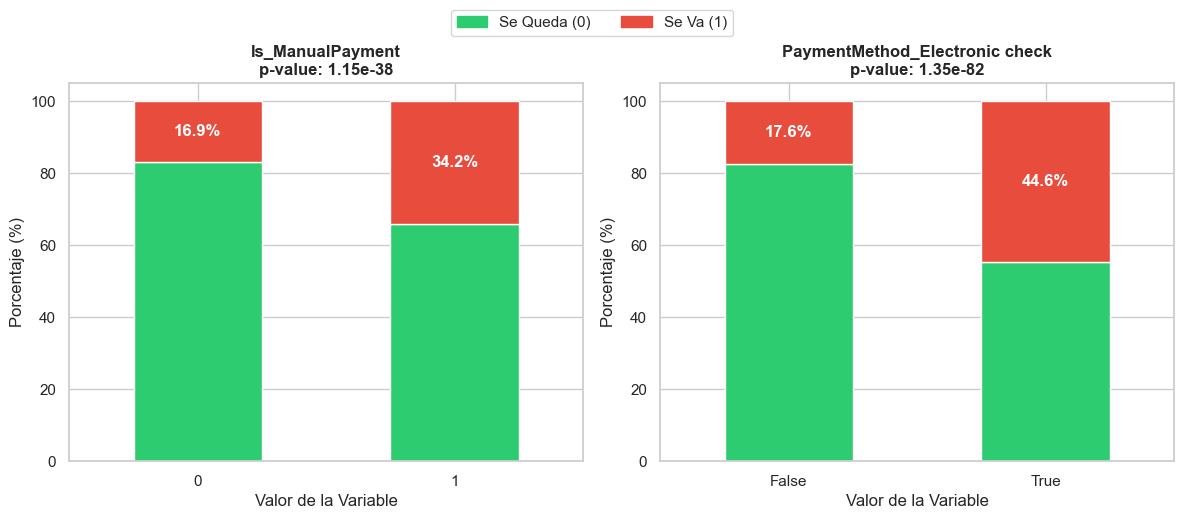

In [11]:
# IMPACTO DE LAS 2 VARIABLES CATEGORICAS PREDICTORAS EN CHURN

df_cat_viz = X_train_cat.copy()
df_cat_viz['Churn'] = y_train.values

columnas_duelo = ['Is_ManualPayment', 'PaymentMethod_Electronic check']

# 2. Configuración del gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set_theme(style="whitegrid")
colores_churn = ['#2ecc71', '#e74c3c']

# 3. Iterar y graficar proporciones
for i, col in enumerate(columnas_duelo):
    # Calcular tabla de contingencia y proporciones
    crosstab = pd.crosstab(df_cat_viz[col], df_cat_viz['Churn'], normalize='index') * 100
    
    # Calcular Chi-Cuadrado contra Target para ver su fuerza predictiva
    chi2, p_val, _, _ = chi2_contingency(pd.crosstab(df_cat_viz[col], df_cat_viz['Churn']))
    
    # Graficar barras apiladas al 100%
    crosstab.plot(kind='bar', stacked=True, color=colores_churn, ax=axes[i], legend=False)
    
    axes[i].set_title(f'{col}\np-value: {p_val:.2e}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_xlabel('Valor de la Variable')
    axes[i].tick_params(axis='x', rotation=0)
    
    # Agregar los porcentajes de Churn (rojo) en las barras
    for n, x in enumerate(crosstab.index):
        pct_churn = crosstab.loc[x, 1]
        axes[i].text(n, 100 - (pct_churn / 2), f'{pct_churn:.1f}%', 
                     ha='center', va='center', color='white', fontweight='bold')

# Leyenda global
handles = [plt.Rectangle((0,0),1,1, color=colores_churn[0]), plt.Rectangle((0,0),1,1, color=colores_churn[1])]
fig.legend(handles, ['Se Queda (0)', 'Se Va (1)'], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.tight_layout()
plt.show()

In [12]:
# IMPACTO DE TODAS LAS VARIABLES CATEGORICAS PREDICTORAS EN CHURN

resultados_chi2 = []

# Iteramos sobre todas las variables categóricas que nos quedan
for col in X_train_cat.columns:
    if col != 'Is_ManualPayment':
        # Tabla cruzada
        crosstab = pd.crosstab(X_train_cat[col], y_train)
        # Prueba Chi-Cuadrado
        chi2, p_val, _, _ = chi2_contingency(crosstab)
        
        resultados_chi2.append({
            'Variable': col,
            'p-value': p_val,
            'Relevante (p < 0.05)': 'Sí' if p_val < 0.05 else 'No (Considerar Eliminar)'
        })

df_relevancia = pd.DataFrame(resultados_chi2).sort_values(by='p-value')

print("\n--- Ranking de Relevancia Categórica} vs Churn ---")
display(df_relevancia.reset_index(drop=True))


--- Ranking de Relevancia Categórica} vs Churn ---


,Variable,p-value,Relevante (p < 0.05)
0,Contract_Two year,2.576257e-90,Sí
1,InternetService_Fiber optic,3.725470e-88,Sí
2,PaymentMethod_Electronic check,1.348228e-82,Sí
3,InternetService_No,1.316994e-50,Sí
4,PaperlessBilling,7.424662e-38,Sí
5,OnlineSecurity,2.405179e-31,Sí
6,Contract_One year,5.001786e-31,Sí
7,Dependents,1.266261e-26,Sí
8,TechSupport,3.219366e-25,Sí
9,Partner,3.511657e-21,Sí


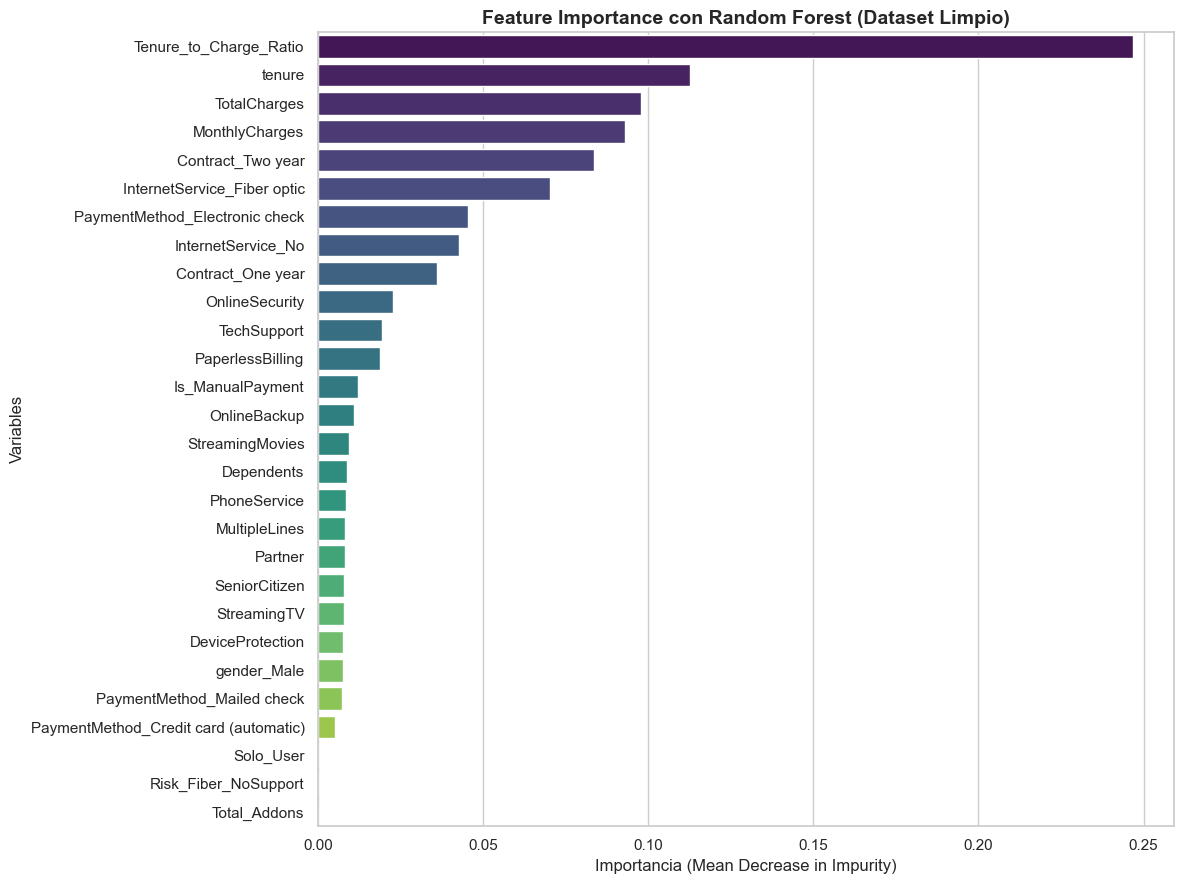

In [13]:
# IDENTIFICAR IMPORTANCIA DE CARACTERISTICAS

# Configurar y entrenar el modelo Random Forest 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extraer y ordenar la importancia de las características de nuestro dataset limpio
importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(12, 9))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis', hue='Variable', legend=False)
plt.title('Feature Importance con Random Forest (Dataset Limpio)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# 1. Variables inútiles definitivas (Ruido comprobado por Chi-Cuadrado y Random Forest)
variables_ruido = [
    'gender_Male', 'PhoneService', 'MultipleLines', 
    'Solo_User', 'Risk_Fiber_NoSupport', 'Total_Addons'
]

# 2. Variables con multicolinealidad
cols_colineales = ['TotalCharges', 'Tenure_to_Charge_Ratio', 'Is_ManualPayment']

# =========================================================================
# --- RUTA A: PURGA MANUAL (Enfoque de Estadística Clásica) ---
# Eliminamos el ruido Y las variables colineales para cuidar la matemática
# =========================================================================
columnas_a_purgar = variables_ruido + cols_colineales

X_train_manual = X_train.drop(columns=[col for col in columnas_a_purgar if col in X_train.columns], errors='ignore')
X_val_manual = X_val.drop(columns=[col for col in columnas_a_purgar if col in X_val.columns], errors='ignore')
X_test_kaggle_manual = X_test_kaggle.drop(columns=[col for col in columnas_a_purgar if col in X_test_kaggle.columns], errors='ignore')

# =========================================================================
# --- RUTA B: FULL DATA (Enfoque de Regularización L1/L2) ---
# NO eliminamos ninguna variable. Dejamos que los hiperparámetros (Lasso/Ridge) 
# del modelo decidan qué sirve y qué es ruido durante el entrenamiento.
# =========================================================================
X_train_full = X_train.copy()
X_val_full = X_val.copy()
X_test_kaggle_full = X_test_kaggle.copy()

### Desbalanceo de clases

--- Distribución de la Variable Objetivo (Churn) en y_train ---
Clase 0 - Se queda (No Churn): 3310 muestras (73.44%)
Clase 1 - Se va (Churn): 1197 muestras (26.56%)


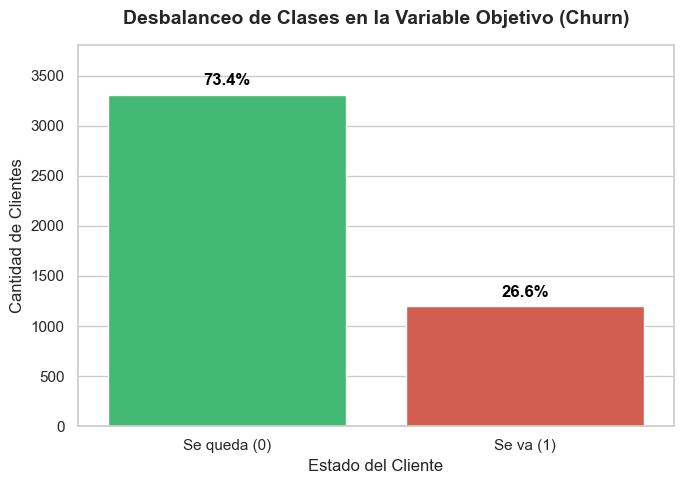

In [15]:
# 1. Calculamos la cantidad y el porcentaje de cada clase
conteos = y_train.value_counts()
porcentajes = y_train.value_counts(normalize=True) * 100

print("--- Distribución de la Variable Objetivo (Churn) en y_train ---")
for clase, conteo in conteos.items():
    estado = "Se va (Churn)" if clase == 1 else "Se queda (No Churn)"
    print(f"Clase {clase} - {estado}: {conteo} muestras ({porcentajes[clase]:.2f}%)")

# 2. Creamos el gráfico
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=y_train, palette=['#2ecc71', '#e74c3c'], hue=y_train, legend=False)

plt.title('Desbalanceo de Clases en la Variable Objetivo (Churn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Se queda (0)', 'Se va (1)'])

total = len(y_train)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = f'{100 * altura / total:.1f}%'
    ax.annotate(porcentaje, 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='center', 
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='black')

plt.ylim(0, max(conteos) * 1.15) 

plt.tight_layout()
plt.show()

In [ ]:
# 3. Balanceo de clases con SMOTE (Aplicado SOLO al conjunto de entrenamiento)
smote = SMOTE(random_state=42, sampling_strategy=0.428)
X_train_manual_sm, y_train_sm = smote.fit_resample(X_train_manual, y_train)
X_train_full_sm, _ = smote.fit_resample(X_train_full, y_train)

print("--- BALANCEO Y EXPORTACIÓN COMPLETADOS ---")
print(f"Dimensiones de Train Manual (Depurado): {X_train_manual_sm.shape}")
print(f"Dimensiones de Train Full (Intacto): {X_train_full_sm.shape}")

# 4. EXPORTAR A DISCO 
os.makedirs('../data/processed', exist_ok=True)

# Exportar Ruta A (Purga Manual)
joblib.dump(X_train_manual_sm, '../data/processed/X_train_manual_sm.pkl')
joblib.dump(X_val_manual, '../data/processed/X_val_manual.pkl')
joblib.dump(X_test_kaggle_manual, '../data/processed/X_test_kaggle_manual.pkl')

# Exportar Ruta B (Full Data)
joblib.dump(X_train_full_sm, '../data/processed/X_train_full_sm.pkl')
joblib.dump(X_val_full, '../data/processed/X_val_full.pkl')
joblib.dump(X_test_kaggle_full, '../data/processed/X_test_kaggle_full.pkl')

# Exportar Variable Objetivo e IDs (Compartidos para ambas rutas)
joblib.dump(y_train_sm, '../data/processed/y_train_sm.pkl')
joblib.dump(y_val, '../data/processed/y_val.pkl')
joblib.dump(test_ids, '../data/processed/test_ids.pkl')

print("Sets de datos guardados.")

--- BALANCEO Y EXPORTACIÓN COMPLETADOS ---
Dimensiones de Train Manual (Depurado): (4726, 19)
Dimensiones de Train Full (Intacto): (4726, 28)
Sets de datos guardados.
